In [4]:
!pip install --upgrade pip

  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 25.3
    Uninstalling pip-25.3:
      Successfully uninstalled pip-25.3


In [6]:
!pip3 install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 23.9 MB/s  0:00:00 eta 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]


In [8]:
!pip3 install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


LOADING CSV DATASETS
✓ Loaded dataset1: 180000 rows
Total rows loaded: 180000

DATA VALIDATION
✓ Valid data points: 180000

SIGNAL PREPROCESSING

Raw signal  →  range [-0.0054, 0.0076]  mean 0.0000  std 0.0003

Filtering  →  threshold=0.0005  |  active samples=33029/180000  (18.35 %)

PREPROCESSING VISUALISATION


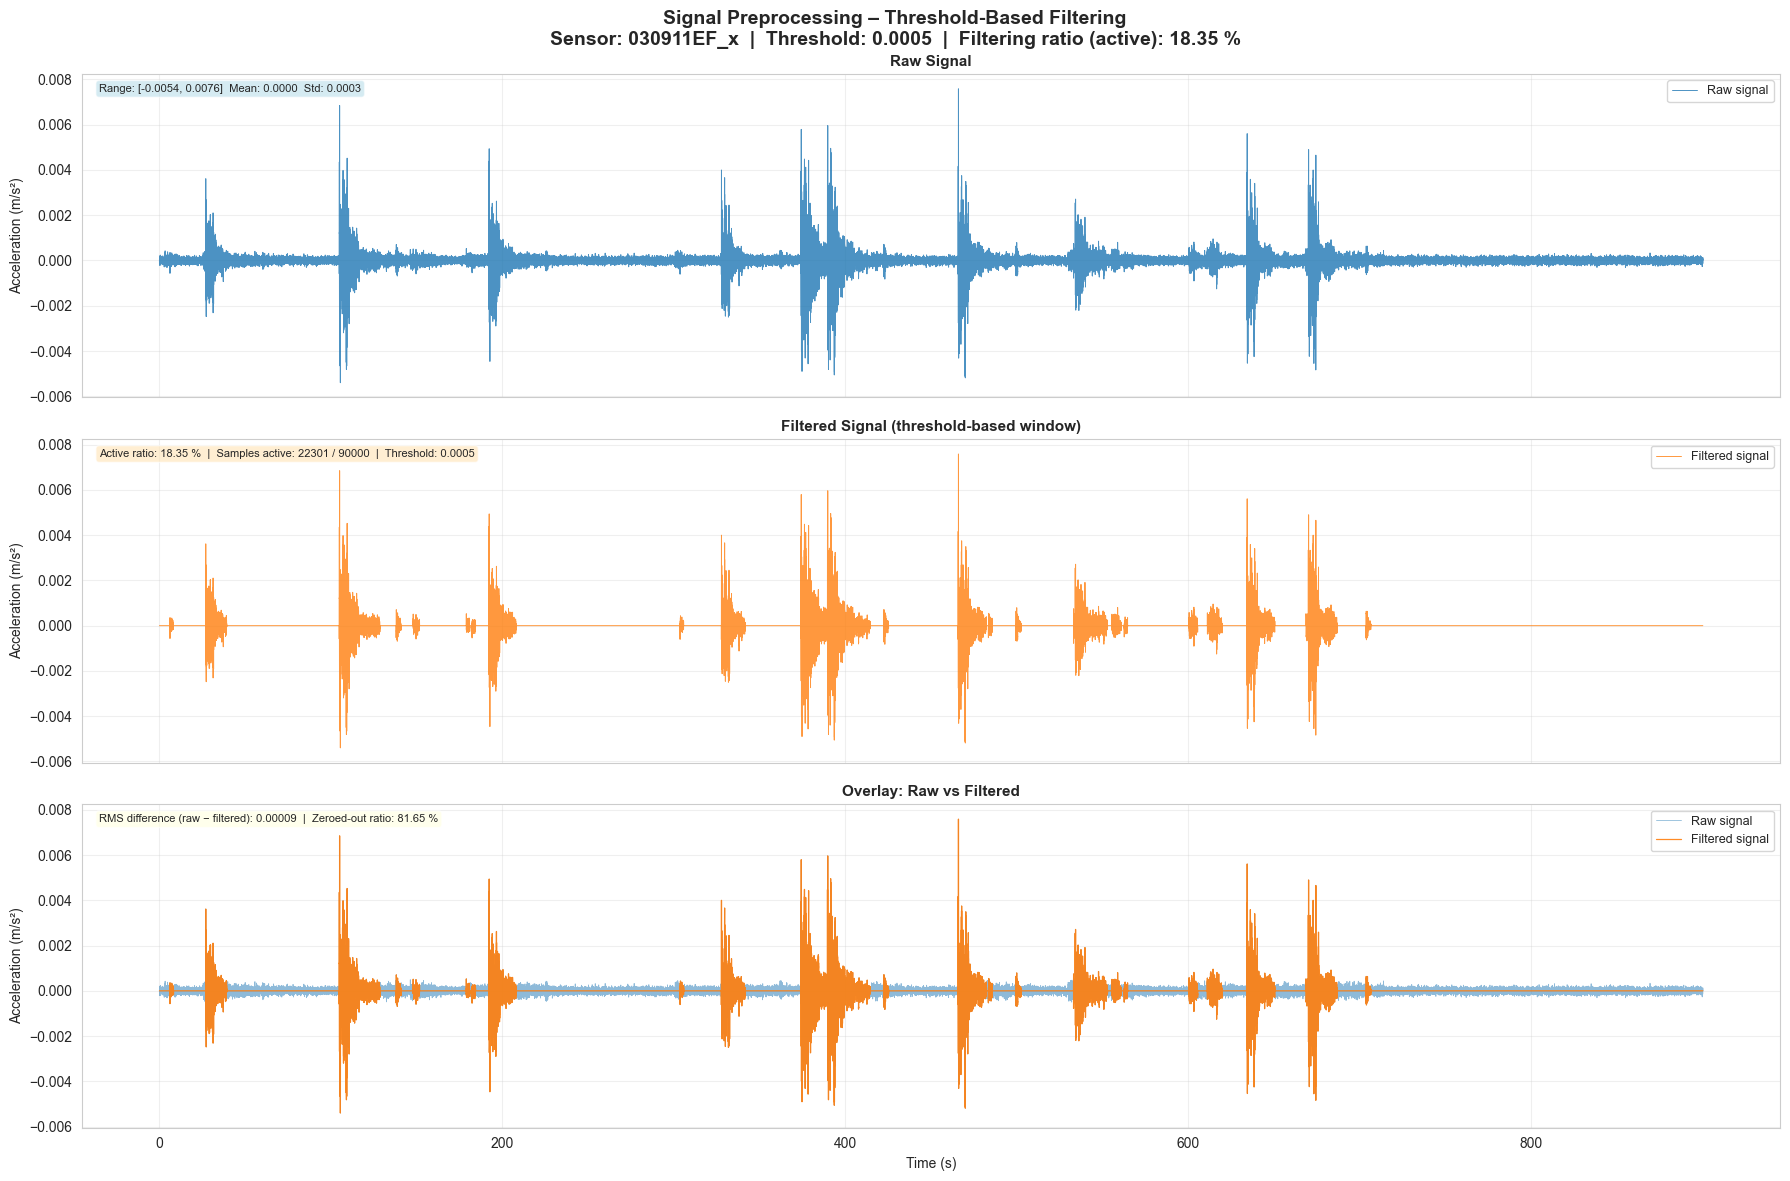

✓ Preprocessing visualisation saved: preprocessing_steps.png

EVENT DETECTION (Vehicle Passage Detection)
Envelope p80 threshold  : 0.000000
Manual threshold used   : 0.0001
Active samples          : 30721 / 180000 (17.07 %)

Initial segments  : 121
After merging     : 35
After duration filter: 35 events

Event durations (s) –  min 1.24  max 39.65  mean 9.18  median 5.06


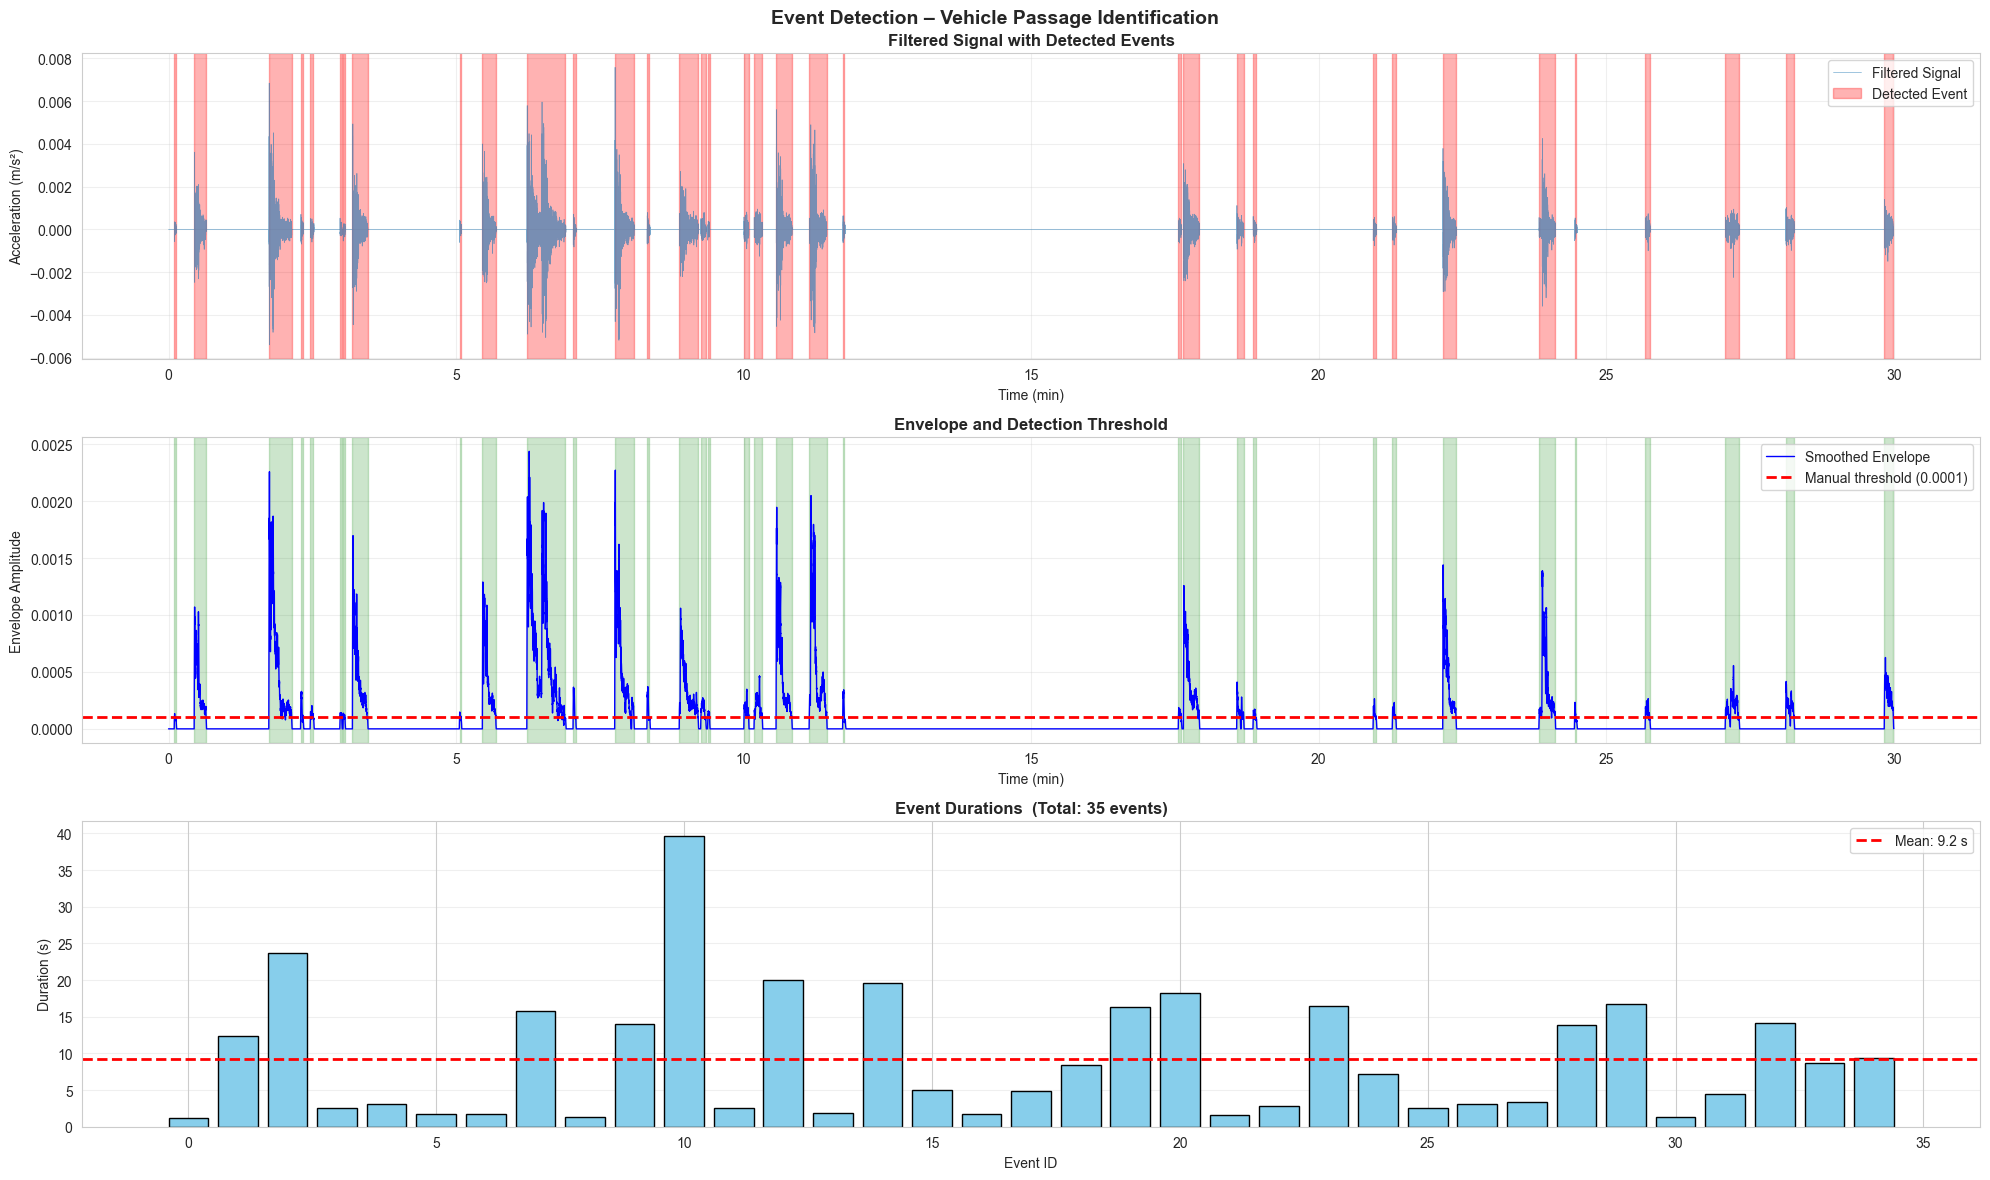

✓ Event detection visualisation saved: event_detection.png

FEATURE EXTRACTION (Per Event – from filtered signal)
Feature matrix shape       : (35, 37)
Features per event         : 37
Total events analysed      : 35

PCA explained variance     : [0.62323356 0.13599798 0.05347336]
Total variance explained   : 0.8127

K-MEANS CLUSTERING
  k=2:  silhouette=0.4557  inertia=612.21
  k=3:  silhouette=0.3554  inertia=476.41
  k=4:  silhouette=0.3018  inertia=379.12
  k=5:  silhouette=0.3062  inertia=325.54
  k=6:  silhouette=0.2957  inertia=272.84
  k=7:  silhouette=0.2379  inertia=250.05
  k=8:  silhouette=0.2594  inertia=213.94
  k=9:  silhouette=0.2475  inertia=192.17
  k=10:  silhouette=0.2463  inertia=168.82

✓ Optimal k=2  |  Silhouette=0.4557  Davies-Bouldin=0.8417  Calinski-Harabasz=36.80
  Cluster 0: 23 events (65.71 %)
  Cluster 1: 12 events (34.29 %)

DBSCAN CLUSTERING
Clusters found : 0
Noise events   : 35 (100.00 %)
  Noise: 35 events (100.00 %)

✓ Results saved: event_clustering

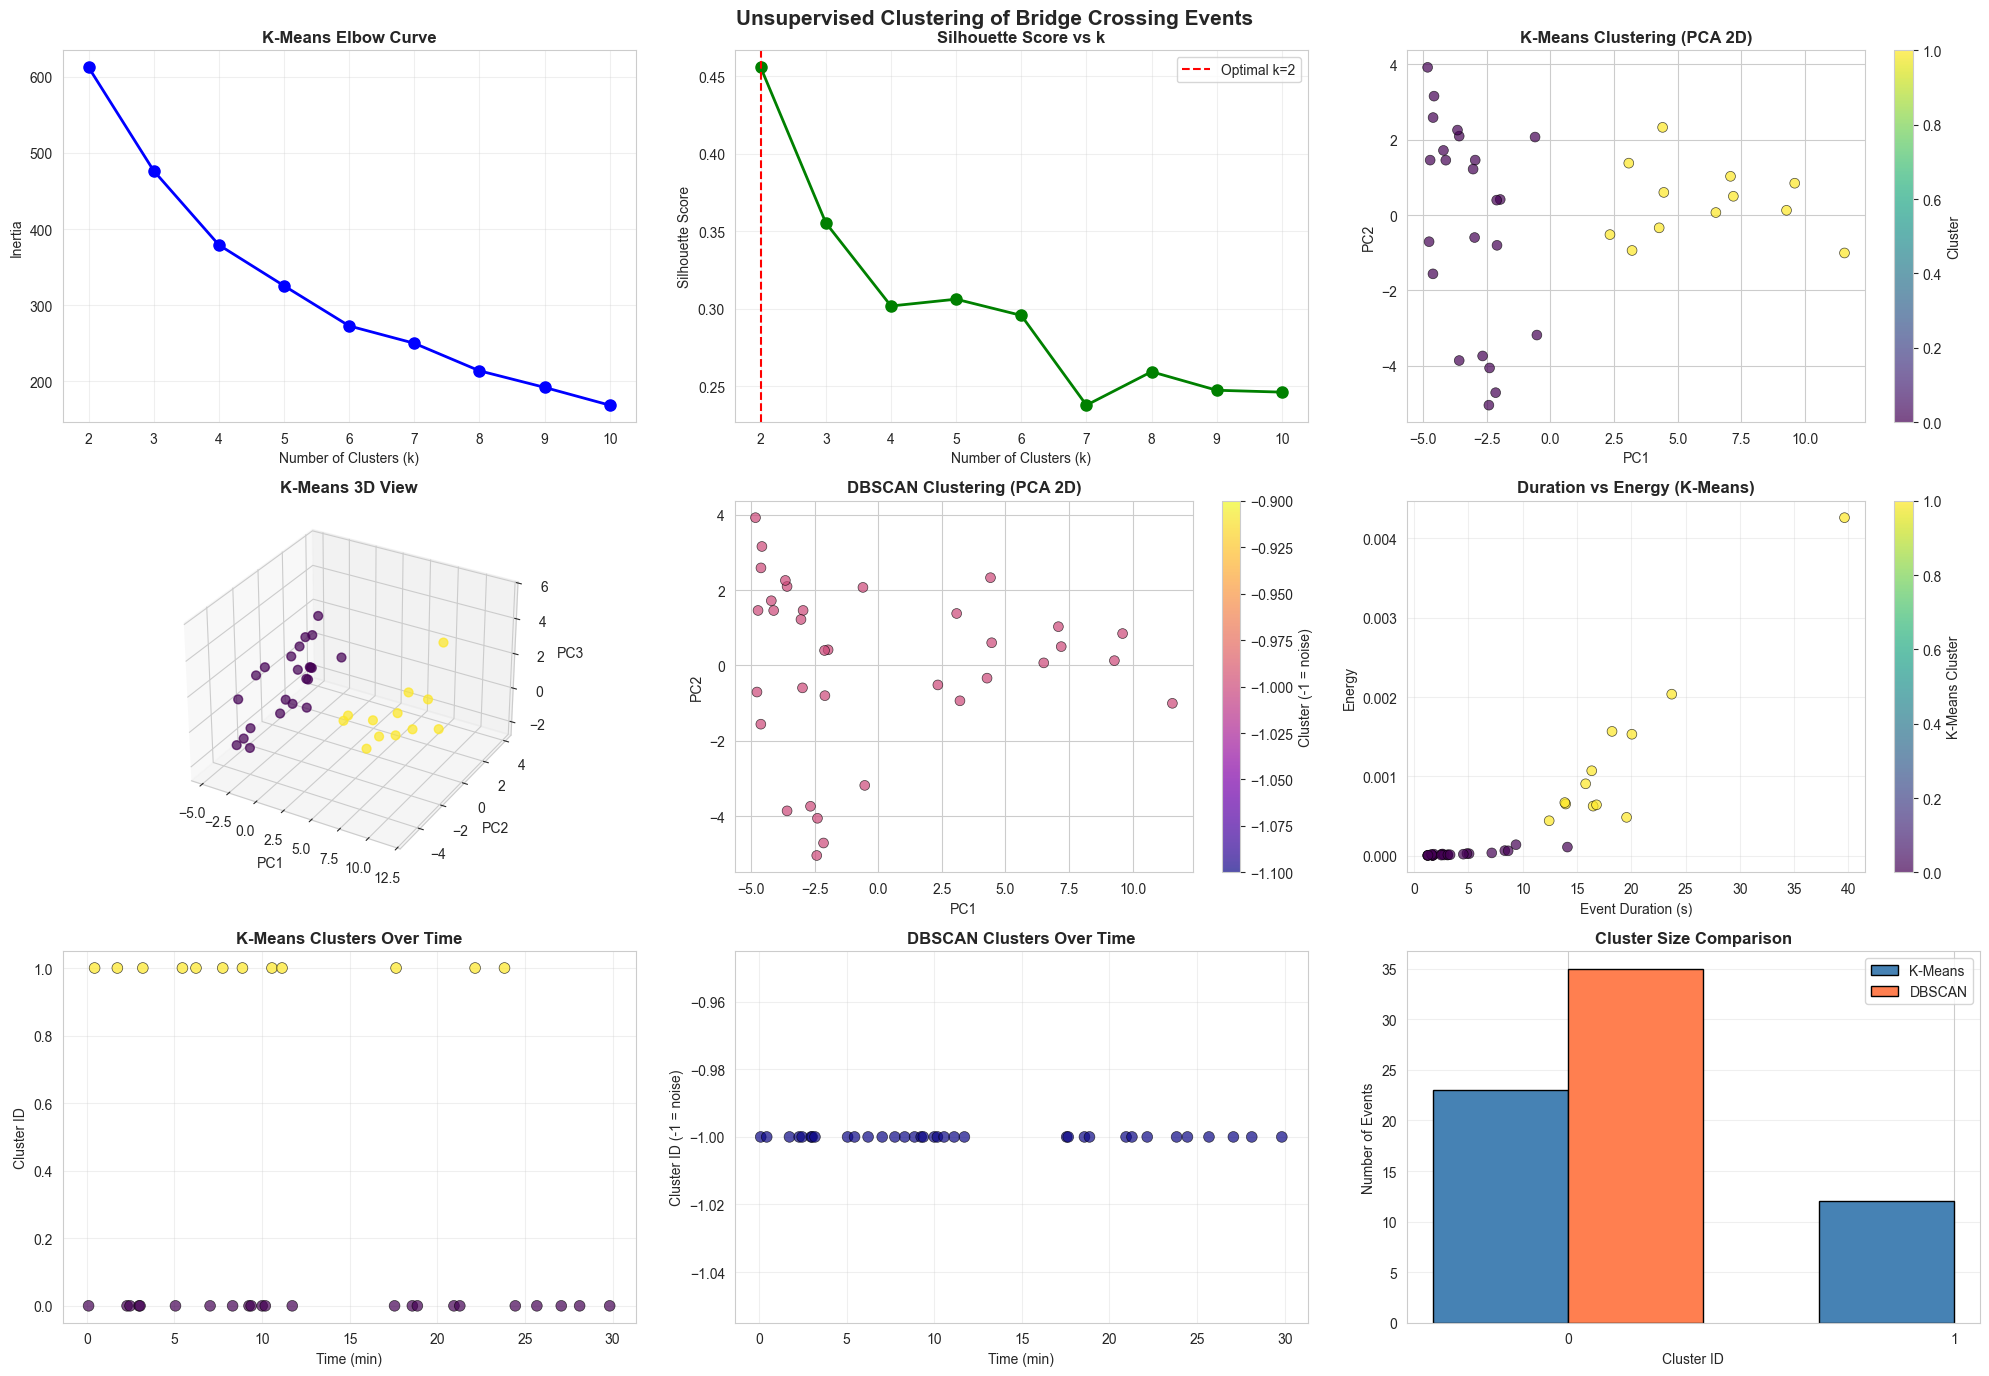

✓ Clustering visualisation saved: event_clustering_visualization.png

ANALYSIS COMPLETE
  Total events analysed    : 35
  Features per event       : 37
  Filtering active ratio   : 18.35 %
  K-Means optimal k        : 2  (Silhouette=0.4557)
  DBSCAN clusters          : 0  (Noise events=35)

Generated files:
  preprocessing_steps.png
  event_detection.png
  event_clustering_visualization.png
  event_clustering_results.csv


In [ ]:
"""
Event-Based Unsupervised Detection for Bridge Monitoring
Uses vertical (Z-direction) acceleration data from CSV files
Implements: Event detection, K-Means, DBSCAN
Each data point = one vehicle crossing event

Pipeline:
  1. Load & validate data
  2. Preprocessing  → raw signal + threshold-based filtered signal (visualised together)
  3. Event detection on filtered signal
  4. Feature extraction from filtered signal (no normalisation on signal)
  5. Clustering (K-Means + DBSCAN) with StandardScaler on feature matrix only
"""

import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.fft import fft
from scipy.ndimage import uniform_filter1d
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'


# ============================================================
# HELPER: Threshold-based window filter
# ============================================================

def _get_filtered_mask(
    sensor_series: pd.Series,
    threshold: float,
    sample_period: int,
    pre_trigger_samples: int = 0,
) -> np.ndarray:
    """
    Return a boolean mask.
    True  → sample is inside an active window
    False → sample is outside every active window.
    """
    n    = len(sensor_series)
    mask = np.zeros(n, dtype=bool)
    vals = sensor_series.to_numpy()

    i = 0
    while i < n:
        if np.abs(vals[i]) >= threshold:
            start = max(i - pre_trigger_samples, 0)
            end   = min(i + sample_period, n)
            while i < end:
                if np.abs(vals[i]) >= threshold:
                    end = min(i + sample_period, n)
                i += 1
            mask[start:end] = True
        else:
            i += 1
    return mask


# ============================================================
# 1. LOAD DATASETS
# ============================================================
print("=" * 60)
print("LOADING CSV DATASETS")
print("=" * 60)

csv_path1 = '/Users/thomas/Data/Data_sensors/20250303/csv_acc/M001_2025-03-03_00-00-00_gg-108_int-1_th.csv'
csv_path2 = '/Users/thomas/Data/Data_sensors/20250208/csv_acc/M001_2025-02-08_01-00-00_gg-83_int-2_th.csv'

SENSOR_COL = '030911EF_x'
fs         = 100   # Hz

try:
    data1 = pd.read_csv(csv_path1, sep=';')
    data1 = data1[[c for c in data1.columns if c == SENSOR_COL or c == 'time']]
    data1 = data1.dropna(subset=[SENSOR_COL])
    data1 = data1[:180000]
    data1[SENSOR_COL] = data1[SENSOR_COL] - data1[SENSOR_COL].mean()   # remove DC offset
    print(f"✓ Loaded dataset1: {len(data1)} rows")
except FileNotFoundError:
    print("⚠ dataset1 not found, skipping...")
    data1 = pd.DataFrame()

data2 = pd.DataFrame()   # placeholder – enable when needed

if not data1.empty and not data2.empty:
    all_data = pd.concat([data1, data2], ignore_index=True)
elif not data1.empty:
    all_data = data1
elif not data2.empty:
    all_data = data2
else:
    raise FileNotFoundError("No CSV files found!")

print(f"Total rows loaded: {len(all_data)}")


# ============================================================
# 2. DATA VALIDATION
# ============================================================
print("\n" + "=" * 60)
print("DATA VALIDATION")
print("=" * 60)

if SENSOR_COL not in all_data.columns:
    raise ValueError(f"CSV must contain '{SENSOR_COL}' column!")

initial_count = len(all_data)
all_data = all_data.dropna(subset=[SENSOR_COL])
dropped  = initial_count - len(all_data)
if dropped:
    print(f"⚠ Dropped {dropped} rows with missing values")

all_data['acceleration'] = pd.to_numeric(all_data[SENSOR_COL], errors='coerce')
all_data = all_data.dropna(subset=['acceleration'])

if len(all_data) == 0:
    raise ValueError("No valid acceleration data found!")

print(f"✓ Valid data points: {len(all_data)}")


# ============================================================
# 3. PREPROCESSING  (raw → threshold-filtered)
# ============================================================
print("\n" + "=" * 60)
print("SIGNAL PREPROCESSING")
print("=" * 60)

# -- Raw signal --
signal_raw = all_data['acceleration'].values.astype(float)

print(f"\nRaw signal  →  range [{signal_raw.min():.4f}, {signal_raw.max():.4f}]"
      f"  mean {signal_raw.mean():.4f}  std {signal_raw.std():.4f}")

# -- Threshold-based filter --
THRESHOLD     = 0.0005
SAMPLE_PERIOD = 200            # samples to extend window after last crossing

sensor_series = pd.Series(signal_raw)
mask          = _get_filtered_mask(sensor_series, THRESHOLD, SAMPLE_PERIOD)

signal_filtered = signal_raw.copy()
signal_filtered[~mask] = 0.0

filtering_ratio = mask.sum() / len(mask)   # fraction of samples kept active

print(f"\nFiltering  →  threshold={THRESHOLD}  |  "
      f"active samples={mask.sum()}/{len(mask)}  "
      f"({filtering_ratio*100:.2f} %)")


# ============================================================
# 4. PREPROCESSING VISUALISATION
#    One figure: overlay + separate subplots + ratio annotation
# ============================================================
print("\n" + "=" * 60)
print("PREPROCESSING VISUALISATION")
print("=" * 60)

n_plot    = min(45000, len(signal_raw))
time_axis = np.arange(n_plot) / fs   # seconds

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
fig.suptitle(
    'Signal Preprocessing – Threshold-Based Filtering\n'
    f'Sensor: {SENSOR_COL}  |  Threshold: {THRESHOLD}  |  '
    f'Filtering ratio (active): {filtering_ratio*100:.2f} %',
    fontsize=14, fontweight='bold'
)

# --- subplot 1: raw signal ---
axes[0].plot(time_axis, signal_raw[:n_plot],
             linewidth=0.7, color='#1f77b4', alpha=0.8, label='Raw signal')
axes[0].set_ylabel('Acceleration (m/s²)')
axes[0].set_title('Raw Signal', fontsize=11, fontweight='bold')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# annotation: raw stats
axes[0].text(
    0.01, 0.97,
    f"Range: [{signal_raw.min():.4f}, {signal_raw.max():.4f}]  "
    f"Mean: {signal_raw.mean():.4f}  Std: {signal_raw.std():.4f}",
    transform=axes[0].transAxes, fontsize=8, va='top',
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5)
)

# --- subplot 2: filtered signal ---
axes[1].plot(time_axis, signal_filtered[:n_plot],
             linewidth=0.7, color='#ff7f0e', alpha=0.8, label='Filtered signal')
axes[1].set_ylabel('Acceleration (m/s²)')
axes[1].set_title('Filtered Signal (threshold-based window)', fontsize=11, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(True, alpha=0.3)

# annotation: filter ratio
active_filtered = signal_filtered[:n_plot]
axes[1].text(
    0.01, 0.97,
    f"Active ratio: {filtering_ratio*100:.2f} %  |  "
    f"Samples active: {mask[:n_plot].sum()} / {n_plot}  |  "
    f"Threshold: {THRESHOLD}",
    transform=axes[1].transAxes, fontsize=8, va='top',
    bbox=dict(boxstyle='round', facecolor='moccasin', alpha=0.6)
)

# --- subplot 3: overlay ---
axes[2].plot(time_axis, signal_raw[:n_plot],
             linewidth=0.6, color='#1f77b4', alpha=0.5, label='Raw signal')
axes[2].plot(time_axis, signal_filtered[:n_plot],
             linewidth=0.9, color='#ff7f0e', alpha=0.9, label='Filtered signal')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Acceleration (m/s²)')
axes[2].set_title('Overlay: Raw vs Filtered', fontsize=11, fontweight='bold')
axes[2].legend(loc='upper right', fontsize=9)
axes[2].grid(True, alpha=0.3)

# annotation: difference summary
diff_rms = np.sqrt(np.mean((signal_raw[:n_plot] - signal_filtered[:n_plot]) ** 2))
axes[2].text(
    0.01, 0.97,
    f"RMS difference (raw − filtered): {diff_rms:.5f}  |  "
    f"Zeroed-out ratio: {(1 - filtering_ratio)*100:.2f} %",
    transform=axes[2].transAxes, fontsize=8, va='top',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.6)
)

plt.tight_layout()
plt.savefig('preprocessing_steps.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Preprocessing visualisation saved: preprocessing_steps.png")
plt.close()


# ============================================================
# 5. EVENT DETECTION  (on filtered signal)
# ============================================================
print("\n" + "=" * 60)
print("EVENT DETECTION (Vehicle Passage Detection)")
print("=" * 60)

envelope        = np.abs(signal_filtered)
smooth_N        = max(1, int(fs * 0.5))            # 0.5 s smoothing
envelope_smooth = uniform_filter1d(envelope, size=smooth_N)

manual_threshold = 0.00010
is_active        = envelope_smooth > manual_threshold

threshold_p80 = np.percentile(envelope_smooth, 80)
print(f"Envelope p80 threshold  : {threshold_p80:.6f}")
print(f"Manual threshold used   : {manual_threshold}")
print(f"Active samples          : {np.sum(is_active)} / {len(is_active)} "
      f"({100*np.sum(is_active)/len(is_active):.2f} %)")

min_event_N = int(1 * fs)    # 1.5 s minimum event duration
merge_gap_N = int(1.5 * fs)    # merge gaps < 1 s

# --- find raw segments ---
raw_segments = []
start = None
for i, active in enumerate(is_active):
    if active and start is None:
        start = i
    elif not active and start is not None:
        raw_segments.append((start, i))
        start = None
if start is not None:
    raw_segments.append((start, len(is_active)))

# --- merge close segments ---
merged = []
for s, e in raw_segments:
    if not merged:
        merged.append([s, e])
    else:
        if s - merged[-1][1] <= merge_gap_N:
            merged[-1][1] = e
        else:
            merged.append([s, e])

# --- filter by minimum duration ---
event_segments = [(s, e) for s, e in merged if (e - s) >= min_event_N]

print(f"\nInitial segments  : {len(raw_segments)}")
print(f"After merging     : {len(merged)}")
print(f"After duration filter: {len(event_segments)} events")

if len(event_segments) == 0:
    raise ValueError("No events detected – adjust manual_threshold or min_event_sec")

durations = [(e - s) / fs for s, e in event_segments]
print(f"\nEvent durations (s) –  min {min(durations):.2f}  "
      f"max {max(durations):.2f}  mean {np.mean(durations):.2f}  "
      f"median {np.median(durations):.2f}")

# --- visualise event detection ---
fig, axes = plt.subplots(3, 1, figsize=(20, 12))
fig.suptitle('Event Detection – Vehicle Passage Identification', fontsize=14, fontweight='bold')

time_min = np.arange(len(signal_filtered)) / fs / 60

ax = axes[0]
ax.plot(time_min, signal_filtered, linewidth=0.5, alpha=0.6, label='Filtered Signal')
for i, (s, e) in enumerate(event_segments):
    ax.axvspan(s/fs/60, e/fs/60, alpha=0.3, color='red',
               label='Detected Event' if i == 0 else '')
ax.set_xlabel('Time (min)')
ax.set_ylabel('Acceleration (m/s²)')
ax.set_title('Filtered Signal with Detected Events', fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(time_min, envelope_smooth, linewidth=1, label='Smoothed Envelope', color='blue')
ax.axhline(y=manual_threshold, color='red', linestyle='--', linewidth=2,
           label=f'Manual threshold ({manual_threshold})')
for s, e in event_segments:
    ax.axvspan(s/fs/60, e/fs/60, alpha=0.2, color='green')
ax.set_xlabel('Time (min)')
ax.set_ylabel('Envelope Amplitude')
ax.set_title('Envelope and Detection Threshold', fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.bar(np.arange(len(event_segments)), durations, color='skyblue', edgecolor='black')
ax.axhline(y=np.mean(durations), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {np.mean(durations):.1f} s')
ax.set_xlabel('Event ID')
ax.set_ylabel('Duration (s)')
ax.set_title(f'Event Durations  (Total: {len(event_segments)} events)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('event_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Event detection visualisation saved: event_detection.png")
plt.close()


# ============================================================
# 6. FEATURE EXTRACTION  (from filtered signal, no signal normalisation)
# ============================================================
print("\n" + "=" * 60)
print("FEATURE EXTRACTION (Per Event – from filtered signal)")
print("=" * 60)

features    = []
event_info  = []

for event_id, (start, end) in enumerate(event_segments):
    seg           = signal_filtered[start:end]          # raw filtered values
    duration_sec  = (end - start) / fs
    start_time_min = start / fs / 60

    # ---- time-domain statistics ----
    mean_val    = np.mean(seg)
    std_val     = np.std(seg)
    var_val     = np.var(seg)
    min_val     = np.min(seg)
    max_val     = np.max(seg)
    range_val   = max_val - min_val
    rms_val     = np.sqrt(np.mean(seg ** 2))
    skew_val    = skew(seg)
    kurt_val    = kurtosis(seg)

    # ---- peak metrics ----
    peak_pos     = np.max(seg)
    peak_neg     = np.abs(np.min(seg))
    peak_overall = np.max(np.abs(seg))

    # ---- energy & shape factors ----
    energy         = np.sum(seg ** 2)
    crest_factor   = peak_overall / (rms_val + 1e-10)
    shape_factor   = rms_val / (np.mean(np.abs(seg)) + 1e-10)
    impulse_factor = peak_overall / (np.mean(np.abs(seg)) + 1e-10)

    # ---- envelope ----
    envelope_mean = np.mean(np.abs(seg))
    envelope_max  = np.max(np.abs(seg))
    envelope_std  = np.std(np.abs(seg))

    # ---- zero-crossing rate ----
    zcr = np.sum(np.diff(np.sign(seg)) != 0) / len(seg)

    # ---- percentiles ----
    p25 = np.percentile(seg, 25)
    p50 = np.percentile(seg, 50)
    p75 = np.percentile(seg, 75)
    iqr = p75 - p25

    # ---- frequency-domain ----
    spec  = np.abs(fft(seg))
    spec  = spec[:len(spec) // 2]
    freqs = np.linspace(0, fs / 2, len(spec))

    dom_freq_idx       = np.argmax(spec)
    dom_freq           = freqs[dom_freq_idx]
    dom_freq_magnitude = spec[dom_freq_idx]
    mean_freq          = np.mean(spec)
    spectral_centroid  = np.sum(freqs * spec) / (np.sum(spec) + 1e-10)
    spectral_std       = np.sqrt(
        np.sum(((freqs - spectral_centroid) ** 2) * spec) / (np.sum(spec) + 1e-10)
    )

    cumsum_energy  = np.cumsum(spec ** 2)
    total_energy   = cumsum_energy[-1]
    rolloff_idx    = np.where(cumsum_energy >= 0.85 * total_energy)[0]
    spectral_rolloff = freqs[rolloff_idx[0]] if len(rolloff_idx) > 0 else fs / 2

    psd = np.sum(spec ** 2)

    spec_norm        = spec / (np.sum(spec) + 1e-10)
    spectral_entropy = -np.sum(spec_norm * np.log(spec_norm + 1e-10))

    # ---- frequency band energies ----
    low_mask  = freqs < 3.0
    mid_mask  = (freqs >= 3.0) & (freqs < 8.0)
    high_mask = freqs >= 8.0

    energy_low  = np.sum(spec[low_mask]  ** 2) if np.any(low_mask)  else 0
    energy_mid  = np.sum(spec[mid_mask]  ** 2) if np.any(mid_mask)  else 0
    energy_high = np.sum(spec[high_mask] ** 2) if np.any(high_mask) else 0
    total_band  = energy_low + energy_mid + energy_high + 1e-10

    event_features = np.array([
        # metadata (2)
        duration_sec, start_time_min,
        # statistics (9)
        mean_val, std_val, var_val, min_val, max_val, range_val, rms_val, skew_val, kurt_val,
        # peaks (3)
        peak_pos, peak_neg, peak_overall,
        # energy & shape (4)
        energy, crest_factor, shape_factor, impulse_factor,
        # envelope (3)
        envelope_mean, envelope_max, envelope_std,
        # zcr (1)
        zcr,
        # percentiles (4)
        p25, p50, p75, iqr,
        # frequency (8)
        dom_freq, dom_freq_magnitude, mean_freq,
        spectral_centroid, spectral_std, spectral_rolloff, psd, spectral_entropy,
        # band ratios (3)
        energy_low / total_band, energy_mid / total_band, energy_high / total_band,
    ])

    features.append(event_features)
    event_info.append({
        'event_id':       event_id,
        'start_sample':   start,
        'end_sample':     end,
        'duration_sec':   duration_sec,
        'start_time_min': start_time_min,
    })

features = np.array(features)

feature_names = [
    'duration_sec', 'start_time_min',
    'mean', 'std', 'var', 'min', 'max', 'range', 'rms', 'skew', 'kurtosis',
    'peak_pos', 'peak_neg', 'peak_overall',
    'energy', 'crest_factor', 'shape_factor', 'impulse_factor',
    'envelope_mean', 'envelope_max', 'envelope_std',
    'zcr',
    'p25', 'p50', 'p75', 'iqr',
    'dom_freq', 'dom_freq_mag', 'mean_freq',
    'spectral_centroid', 'spectral_std', 'spectral_rolloff', 'psd', 'spectral_entropy',
    'energy_low', 'energy_mid', 'energy_high',
]

print(f"Feature matrix shape       : {features.shape}")
print(f"Features per event         : {features.shape[1]}")
print(f"Total events analysed      : {len(features)}")


# ============================================================
# 7. FEATURE SCALING  (StandardScaler only for clustering)
# ============================================================
scaler         = StandardScaler()
features_scaled = scaler.fit_transform(features)

# PCA for visualisation
pca          = PCA(n_components=min(3, features_scaled.shape[1]))
features_pca = pca.fit_transform(features_scaled)
print(f"\nPCA explained variance     : {pca.explained_variance_ratio_}")
print(f"Total variance explained   : {np.sum(pca.explained_variance_ratio_):.4f}")

if features_pca.shape[1] < 3:
    pad          = np.zeros((features_pca.shape[0], 3 - features_pca.shape[1]))
    features_pca = np.hstack([features_pca, pad])


# ============================================================
# 8. CLUSTERING – K-MEANS
# ============================================================
print("\n" + "=" * 60)
print("K-MEANS CLUSTERING")
print("=" * 60)

inertias           = []
silhouette_scores_km = []
k_range            = range(2, min(11, len(features)))

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(features_scaled)
    inertias.append(km.inertia_)
    silhouette_scores_km.append(silhouette_score(features_scaled, labels))
    print(f"  k={k}:  silhouette={silhouette_scores_km[-1]:.4f}  inertia={km.inertia_:.2f}")

optimal_k    = k_range[np.argmax(silhouette_scores_km)]
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(features_scaled)

km_sil = silhouette_score(features_scaled, kmeans_labels)
km_db  = davies_bouldin_score(features_scaled, kmeans_labels)
km_ch  = calinski_harabasz_score(features_scaled, kmeans_labels)

print(f"\n✓ Optimal k={optimal_k}  |  Silhouette={km_sil:.4f}  "
      f"Davies-Bouldin={km_db:.4f}  Calinski-Harabasz={km_ch:.2f}")

unique, counts = np.unique(kmeans_labels, return_counts=True)
for cid, cnt in zip(unique, counts):
    print(f"  Cluster {cid}: {cnt} events ({cnt/len(kmeans_labels)*100:.2f} %)")


# ============================================================
# 9. CLUSTERING – DBSCAN
# ============================================================
print("\n" + "=" * 60)
print("DBSCAN CLUSTERING")
print("=" * 60)

dbscan        = DBSCAN(eps=0.5, min_samples=max(2, len(features) // 20))
dbscan_labels = dbscan.fit_predict(features_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise       = list(dbscan_labels).count(-1)

print(f"Clusters found : {n_clusters_db}")
print(f"Noise events   : {n_noise} ({n_noise/len(dbscan_labels)*100:.2f} %)")

if n_clusters_db > 1:
    valid = dbscan_labels != -1
    if valid.sum() > 0:
        db_sil = silhouette_score(features_scaled[valid], dbscan_labels[valid])
        print(f"Silhouette Score (excl. noise): {db_sil:.4f}")

unique_db, counts_db = np.unique(dbscan_labels, return_counts=True)
for cid, cnt in zip(unique_db, counts_db):
    tag = "Noise" if cid == -1 else f"Cluster {cid}"
    print(f"  {tag}: {cnt} events ({cnt/len(dbscan_labels)*100:.2f} %)")


# ============================================================
# 10. RESULTS DATAFRAME
# ============================================================
results_df = pd.DataFrame({
    'event_id':       [i['event_id']       for i in event_info],
    'start_sample':   [i['start_sample']   for i in event_info],
    'end_sample':     [i['end_sample']      for i in event_info],
    'duration_sec':   [i['duration_sec']    for i in event_info],
    'start_time_min': [i['start_time_min']  for i in event_info],
    'kmeans_cluster': kmeans_labels,
    'dbscan_cluster': dbscan_labels,
    'pca_1':          features_pca[:, 0],
    'pca_2':          features_pca[:, 1],
    'pca_3':          features_pca[:, 2],
})
# attach key signal-level features (from unscaled matrix)
results_df['peak_acceleration'] = features[:, feature_names.index('peak_overall')]
results_df['rms_acceleration']  = features[:, feature_names.index('rms')]
results_df['energy']            = features[:, feature_names.index('energy')]
results_df['dominant_freq']     = features[:, feature_names.index('dom_freq')]
results_df['spectral_centroid'] = features[:, feature_names.index('spectral_centroid')]

results_df.to_csv('event_clustering_results.csv', index=False)
print("\n✓ Results saved: event_clustering_results.csv")


# ============================================================
# 11. CLUSTERING VISUALISATION
# ============================================================
print("\nGenerating clustering visualisations...")

fig = plt.figure(figsize=(20, 14))
fig.suptitle('Unsupervised Clustering of Bridge Crossing Events', fontsize=15, fontweight='bold')

# --- 1. Elbow curve ---
ax1 = plt.subplot(3, 3, 1)
ax1.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('K-Means Elbow Curve', fontweight='bold')
ax1.grid(True, alpha=0.3)

# --- 2. Silhouette scores ---
ax2 = plt.subplot(3, 3, 2)
ax2.plot(list(k_range), silhouette_scores_km, 'go-', linewidth=2, markersize=8)
ax2.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal k={optimal_k}')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs k', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- 3. K-Means PCA 2D ---
ax3 = plt.subplot(3, 3, 3)
sc = ax3.scatter(features_pca[:, 0], features_pca[:, 1],
                 c=kmeans_labels, cmap='viridis', alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
plt.colorbar(sc, ax=ax3, label='Cluster')
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.set_title('K-Means Clustering (PCA 2D)', fontweight='bold')

# --- 4. K-Means PCA 3D ---
ax4 = plt.subplot(3, 3, 4, projection='3d')
ax4.scatter(features_pca[:, 0], features_pca[:, 1], features_pca[:, 2],
            c=kmeans_labels, cmap='viridis', alpha=0.7, s=40)
ax4.set_xlabel('PC1')
ax4.set_ylabel('PC2')
ax4.set_zlabel('PC3')
ax4.set_title('K-Means 3D View', fontweight='bold')

# --- 5. DBSCAN PCA 2D ---
ax5 = plt.subplot(3, 3, 5)
sc2 = ax5.scatter(features_pca[:, 0], features_pca[:, 1],
                  c=dbscan_labels, cmap='plasma', alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
plt.colorbar(sc2, ax=ax5, label='Cluster (-1 = noise)')
ax5.set_xlabel('PC1')
ax5.set_ylabel('PC2')
ax5.set_title('DBSCAN Clustering (PCA 2D)', fontweight='bold')

# --- 6. Event duration vs energy (coloured by K-Means) ---
ax6 = plt.subplot(3, 3, 6)
sc3 = ax6.scatter(results_df['duration_sec'], results_df['energy'],
                  c=kmeans_labels, cmap='viridis', alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
plt.colorbar(sc3, ax=ax6, label='K-Means Cluster')
ax6.set_xlabel('Event Duration (s)')
ax6.set_ylabel('Energy')
ax6.set_title('Duration vs Energy (K-Means)', fontweight='bold')
ax6.grid(True, alpha=0.3)

# --- 7. Cluster timeline – K-Means ---
ax7 = plt.subplot(3, 3, 7)
ax7.scatter(results_df['start_time_min'], kmeans_labels,
            c=kmeans_labels, cmap='viridis', s=60, alpha=0.7, edgecolors='black', linewidth=0.5)
ax7.set_xlabel('Time (min)')
ax7.set_ylabel('Cluster ID')
ax7.set_title('K-Means Clusters Over Time', fontweight='bold')
ax7.grid(True, alpha=0.3)

# --- 8. Cluster timeline – DBSCAN ---
ax8 = plt.subplot(3, 3, 8)
ax8.scatter(results_df['start_time_min'], dbscan_labels,
            c=dbscan_labels, cmap='plasma', s=60, alpha=0.7, edgecolors='black', linewidth=0.5)
ax8.set_xlabel('Time (min)')
ax8.set_ylabel('Cluster ID (-1 = noise)')
ax8.set_title('DBSCAN Clusters Over Time', fontweight='bold')
ax8.grid(True, alpha=0.3)

# --- 9. Cluster size bar chart (both algorithms) ---
ax9 = plt.subplot(3, 3, 9)
km_ids, km_counts = np.unique(kmeans_labels, return_counts=True)
db_ids, db_counts = np.unique(dbscan_labels, return_counts=True)

x_km = np.arange(len(km_ids))
x_db = np.arange(len(db_ids))
width = 0.35

bars1 = ax9.bar(x_km - width/2, km_counts, width, label='K-Means', color='steelblue', edgecolor='black')
bars2 = ax9.bar(x_db + width/2, db_counts, width, label='DBSCAN',  color='coral',     edgecolor='black')

ax9.set_xlabel('Cluster ID')
ax9.set_ylabel('Number of Events')
ax9.set_title('Cluster Size Comparison', fontweight='bold')
ax9.set_xticks(np.arange(max(len(km_ids), len(db_ids))))
ax9.legend()
ax9.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('event_clustering_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Clustering visualisation saved: event_clustering_visualization.png")
plt.close()


# ============================================================
# SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)
print(f"  Total events analysed    : {len(features)}")
print(f"  Features per event       : {features.shape[1]}")
print(f"  Filtering active ratio   : {filtering_ratio*100:.2f} %")
print(f"  K-Means optimal k        : {optimal_k}  (Silhouette={km_sil:.4f})")
print(f"  DBSCAN clusters          : {n_clusters_db}  (Noise events={n_noise})")
print("\nGenerated files:")
print("  preprocessing_steps.png")
print("  event_detection.png")
print("  event_clustering_visualization.png")
print("  event_clustering_results.csv")
print("=" * 60)